# Capire `vqe_trimer_ring_W.py` — guida interattiva

Questo notebook è il **mirror diretto**, per il trimero (N=3, anello isoscele), di
`vqe_dimer_spiegato.ipynb`: stessa struttura, stessi passi, stesso ansatz PMA "originale"
(gate $W_{ij}(\theta)$, **non** RBS) con **branching esplicito** sullo stato iniziale in
base al campo. Serve come termine di paragone pulito, prima di esplorare (in un notebook
successivo, sul modello di `confronto_ansatz_entangler.ipynb`) se per il trimero il
branching sia evitabile con un ansatz più ricco.

Risponde in modo operativo a:
1. **Perché il VQE dà un limite superiore** all'energia (principio variazionale).
2. **Come l'estimator calcola** $\langle H\rangle_{\boldsymbol\theta}$.
3. **Come sono fatti i due ansätze** — hardware-efficient (HA) e physically motivated (PMA)
   — e perché il PMA usa meno parametri.
4. **Perché il PMA fallisce vicino a $b_c$ con il DM (Opzione B)** — il punto fisico centrale.

> **Prerequisiti:** Qiskit 2.x, `numpy`, `scipy`, `matplotlib`; `ipywidgets` opzionale.
> `trimer_ring_exact.py` e `vqe_trimer_ring_W.py` nella stessa cartella.

Il modello è sempre
$$H_0 = J\,\boldsymbol\sigma_1\cdot\boldsymbol\sigma_2 + J'(\boldsymbol\sigma_2\cdot\boldsymbol\sigma_3+\boldsymbol\sigma_3\cdot\boldsymbol\sigma_1) + b\sum_{i=1}^3 Z_i,$$
con DM opzionale (Opzione B, la sola verificata capace di aprire l'incrocio — vedi
`analisi_dm_trimero.pdf`):
$$H_{DM} = r\big[J(X_1Z_2-Z_1X_2) + J'(X_2Z_3-Z_2X_3) + J'(X_3Z_1-Z_3X_1)\big].$$

## 0. Setup

In [1]:
import numpy as np
from scipy.optimize import minimize

from qiskit.primitives import StatevectorEstimator
from qiskit.circuit.library import n_local
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.quantum_info import Statevector, Operator

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", message=".*default.json.*")
warnings.filterwarnings("ignore", message="Style JSON file")

from trimer_ring_exact import (
    trimer_hamiltonian, exact_sweep, critical_field,
    magnetization_operator, kambe_states, ground_state_projector,
    trimer_hamiltonian_dm, exact_sweep_dm, ground_state_projector_dm,
)
from vqe_trimer_ring_W import (
    make_ha_ansatz, make_pma_ansatz, make_pma_ansatz_forced, w_block,
    _select_target_block, _prepare_initial_state,
    run_vqe, run_vqe_forced, vqe_sweep, _plot_row,
    BOND12, BOND23, BOND31,
)

try:
    from ipywidgets import interact, interact_manual, FloatSlider, IntSlider, Dropdown
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

print("Setup OK. Slider interattivi:", "si" if HAS_WIDGETS else "no (fallback statico)")


def show_circuit(qc, decompose=True):
    c = qc.decompose() if decompose else qc
    try:
        display(c.draw("mpl", style="iqp"))
    except Exception:
        print(c.draw())


def _mostra_figura(fig):
    from IPython.display import display as _d
    _d(fig)
    plt.close(fig)

Setup OK. Slider interattivi: si


## 1. Il principio variazionale

Stesso teorema del dimero, qui su una matrice $8\times8$ invece di $4\times4$: per
**qualsiasi** stato normalizzato $\ket\psi$,
$$\langle\psi|H|\psi\rangle \;\geq\; E_0,$$
con $E_0$ l'energia del ground state. Verifico con stati casuali a 3 qubit.

In [2]:
J, Jp = 1.0, 0.4
H = trimer_hamiltonian(J, Jp, b=1.0).to_matrix()
E0 = float(np.linalg.eigvalsh(H)[0])
print(f"E0 (esatto) = {E0:.4f}\n")

rng = np.random.default_rng(0)
for _ in range(6):
    psi = rng.normal(size=8) + 1j * rng.normal(size=8)
    psi /= np.linalg.norm(psi)
    E = float(np.real(psi.conj() @ H @ psi))
    print(f"  stato casuale: <H> = {E:8.4f}   >= E0 ? {E >= E0 - 1e-12}")

E0 (esatto) = -4.0000

  stato casuale: <H> =   0.8523   >= E0 ? True
  stato casuale: <H> =   0.0886   >= E0 ? True
  stato casuale: <H> =   0.2614   >= E0 ? True
  stato casuale: <H> =   0.2762   >= E0 ? True
  stato casuale: <H> =  -1.7086   >= E0 ? True
  stato casuale: <H> =  -0.8302   >= E0 ? True


## 2. L'estimator: come si calcola $\langle H\rangle$

Stesso pattern del dimero: PUB `(ansatz, hamiltonian, [params])`, `StatevectorEstimator`,
`.evs.item()`. Verifico che coincida col calcolo manuale via `Statevector`, qui su un
ansatz a 3 qubit.

In [3]:
ansatz = n_local(3, "ry", "cz", entanglement="full", reps=2)
H_op = trimer_hamiltonian(J, Jp, b=1.0)
estimator = StatevectorEstimator()

params = np.linspace(0.1, 1.2, ansatz.num_parameters)

pub = (ansatz, H_op, [params])
E_est = estimator.run([pub]).result()[0].data.evs.item()

sv = Statevector(ansatz.assign_parameters(params)).data
E_man = float(np.real(sv.conj() @ H_op.to_matrix() @ sv))

print(f"<H> estimator = {E_est:.8f}")
print(f"<H> manuale   = {E_man:.8f}")
print(f"coincidono?     {np.isclose(E_est, E_man)}")

<H> estimator = 1.75143972
<H> manuale   = 1.75143972
coincidono?     True


## 3. L'ansatz hardware-efficient (HA)

Come nel dimero, `n_local`: strati $R_y$ + $CZ$, generico, nessuna struttura fisica.
Numero di parametri: $3(\text{reps}+1)$ (3 qubit invece di 2). Per `reps=2`: 9 parametri.

Parametri HA (reps=2): 9


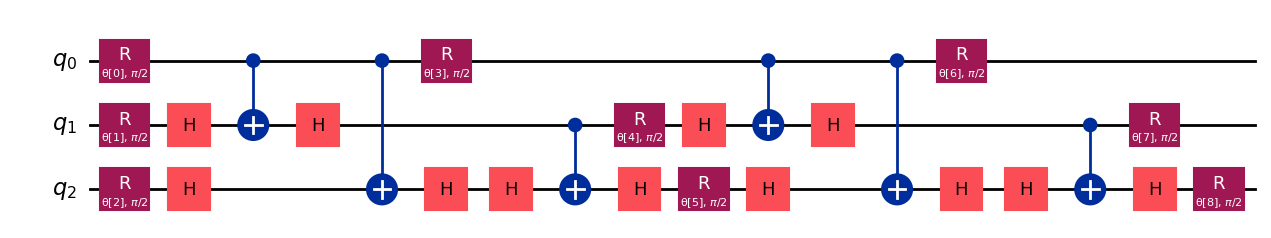

In [4]:
ha = make_ha_ansatz(reps=2)
print("Parametri HA (reps=2):", ha.num_parameters)
show_circuit(ha)

## 4. L'ansatz physically motivated (PMA)

Stesso principio del dimero, esteso ai **tre legami** del triangolo. Il blocco fondamentale
agisce su ogni legame $(i,j)$, identico gate del dimero:
$$W_{ij}(\theta) = \text{CNOT}_{ij}\,\big(R_y(\theta)_i\otimes I_j\big)\,\text{CNOT}_{ij}.$$

Lo stato iniziale rispetta la simmetria del ground state atteso (decomposizione di Kambe):
- $b < b_c$: si parte dal multipletto a bassa energia ($C$ o $B$, secondo la mappa dei
  segni) — per il punto di lavoro standard ($J{=}1,J'{=}0.4$, zona $C$) è il **singoletto
  locale** sulla coppia base $(1,2)$, più il terzo qubit;
- $b \geq b_c$: si parte da $\ket{A,-\frac32}=\ket{111}$.

Per $K$ layer (uno per legame): **$3K$ parametri** (nessun layer finale di $R_y$
indipendenti — a differenza della versione RBS già validata in `vqe_trimer_ring.py`).

### Perché si sceglie il riferimento in base al campo?

Stessa ragione del dimero: il fondamentale del trimero **cambia multipletto bruscamente**
a $b_c$ (level crossing $C\to A$) — due stati completamente diversi ($S_{12}$ diverso),
non c'è un singolo riferimento fisso che vada bene ovunque con un ansatz $M$-conservante.
L'ansatz quindi **sceglie il ramo** in base al regime, esattamente come nel dimero. La
funzione `make_pma_ansatz` è la stessa in entrambi i casi: cambia solo la preparazione
iniziale, la parte parametrica ($W_{ij}(\theta)$ su ciascun legame) resta identica.

Parametri PMA (K=1): 3

PMA sotto soglia (b<b_c), stato iniziale = singoletto su (1,2) + X su 3:


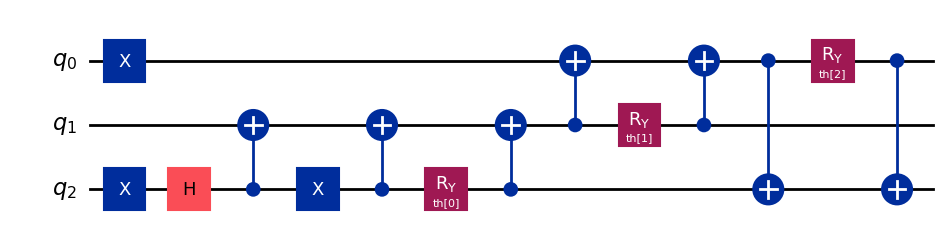


PMA sopra soglia (b>=b_c), stato iniziale = |111>:


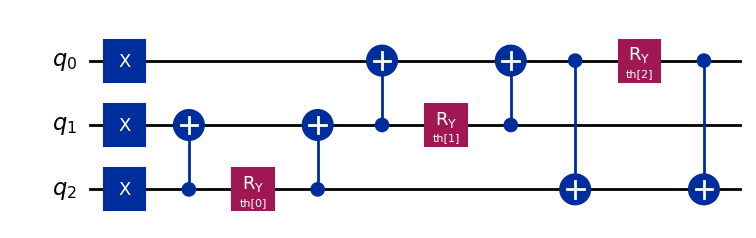

In [5]:
print("Parametri PMA (K=1):", make_pma_ansatz(J, Jp, 1.0).num_parameters)

print("\nPMA sotto soglia (b<b_c), stato iniziale = singoletto su (1,2) + X su 3:")
show_circuit(make_pma_ansatz(J, Jp, 1.0), decompose=False)

print("\nPMA sopra soglia (b>=b_c), stato iniziale = |111>:")
show_circuit(make_pma_ansatz(J, Jp, 3.0), decompose=False)

### Derivazione esplicita: perché $X,H,\mathrm{CX},X$ prepara il singoletto sulla coppia base

Stessa identica derivazione del dimero (la preparazione agisce solo sui qubit 2,1, cioè
siti 1,2 — il terzo qubit resta a $\ket0$ finché non arriva l'eventuale $X$ finale):

| gate | stato dopo (qubit 2,1) |
|---|---|
| (iniziale) | $\ket{00}$ |
| $X(q_2)$ | $\ket{10}$ |
| $H(q_2)$ | $\frac1{\sqrt2}(\ket{00}-\ket{10})$ |
| $\mathrm{CX}(q_2\to q_1)$ | $\frac1{\sqrt2}(\ket{00}-\ket{11})$ |
| $X(q_2)$ | $\frac1{\sqrt2}(\ket{10}-\ket{01}) = -\frac1{\sqrt2}(\ket{01}-\ket{10})$ |

Singoletto a meno di fase globale $-1$, irrilevante fisicamente. Verifico col simulatore,
includendo il terzo qubit (che resta $\ket0$ in questa fase):

In [6]:
qc0 = QuantumCircuit(3)
q1, q2 = 2, 1  # site1, site2
qc0.x(q1); qc0.h(q1); qc0.cx(q1, q2); qc0.x(q1)
sv0 = Statevector(qc0).data
print("Stato dopo la preparazione (prima dell'eventuale X sul sito 3):")
print(np.round(sv0.real, 3))

target = kambe_states()[("C", 0.5)]
print("\nStato di Kambe |C,+1/2> atteso:", np.round(target.real, 3))
overlap = np.vdot(sv0, target)
print(f"|overlap| = {abs(overlap):.6f}  (1 => stessa fisica, a meno di fase)")

Stato dopo la preparazione (prima dell'eventuale X sul sito 3):
[ 0.     0.    -0.707  0.     0.707  0.     0.     0.   ]

Stato di Kambe |C,+1/2> atteso: [ 0.     0.     0.707  0.    -0.707  0.     0.     0.   ]
|overlap| = 1.000000  (1 => stessa fisica, a meno di fase)


### Perché basta $K=1$ per ciascun legame: la struttura a blocchi di $W_{ij}(\theta)$

Identica proprietà del dimero, gate per gate: la matrice $4\times4$ di $W_{ij}(\theta)$
(ristretta alla coppia di qubit su cui agisce, il terzo qubit come spettatore) è
**diagonale a blocchi**, con la **stessa** rotazione sia su $\{\ket{01},\ket{10}\}$ sia su
$\{\ket{00},\ket{11}\}$ — verificato qui isolando il gate a 2 qubit (è letteralmente lo
stesso gate del dimero):

In [7]:
theta_test = 0.7
qc_W = QuantumCircuit(2); qc_W.cx(0, 1); qc_W.ry(theta_test, 0); qc_W.cx(0, 1)
U = Operator(qc_W).data
np.set_printoptions(precision=3, suppress=True)
print("Matrice di W(theta), base |00>,|01>,|10>,|11>:")
print(U.real)

c, s = np.cos(theta_test/2), np.sin(theta_test/2)
print(f"\ncos(theta/2)={c:.3f}  sin(theta/2)={s:.3f}  -> su ENTRAMBI i blocchi diagonali")

Matrice di W(theta), base |00>,|01>,|10>,|11>:
[[ 0.939  0.     0.    -0.343]
 [ 0.     0.939  0.343  0.   ]
 [ 0.    -0.343  0.939  0.   ]
 [ 0.343  0.     0.     0.939]]

cos(theta/2)=0.939  sin(theta/2)=0.343  -> su ENTRAMBI i blocchi diagonali


A $D=0$ (senza DM), lo stato iniziale di ciascun ramo è **già** l'autostato esatto per
tutto il proprio intervallo di $b$ (il singoletto sulla coppia base non dipende da $b$, e
il campo Zeeman non lo sposta in energia entro il proprio settore $M$) — quindi anche
$K=1$ (3 parametri, uno per legame) è già più che sufficiente: l'ottimizzatore trova
$\theta\approx0$ ovunque nel regime $D=0$. La vera necessità dei parametri emerge solo con
il DM acceso (§7).

### Verifica: cosa succede se si forza un ramo su tutto l'asse $b$?

Stesso esperimento del dimero: forzo ciascun ramo (basso/alto campo) su **tutto** l'asse
$b$, non solo dove è quello giusto, e confronto con la forma chiusa esatta.

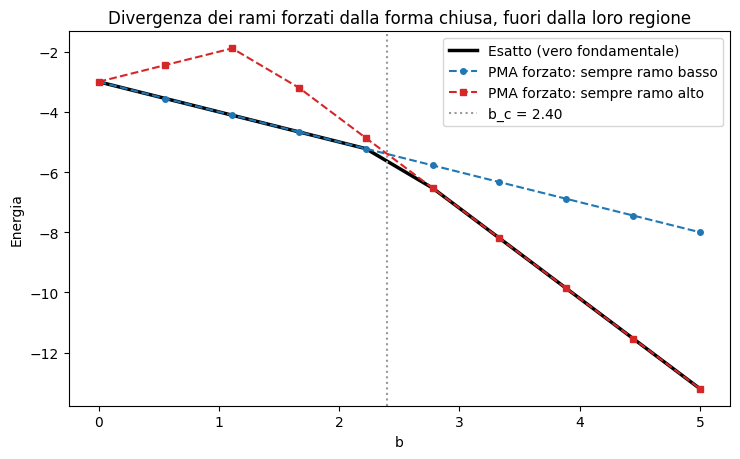

Errore massimo ramo basso per b>b_c: 5.2000
Errore massimo ramo alto per b<b_c:  2.2222
(entrambi crescono allontanandosi da b_c, come nel dimero)


In [8]:
b_vals = np.linspace(0.0, 5.0, 10)
E_basso = np.array([run_vqe_forced(J, Jp, b, "basso", n_restarts=3) for b in b_vals])
E_alto  = np.array([run_vqe_forced(J, Jp, b, "alto",  n_restarts=3) for b in b_vals])
E_esatto = exact_sweep(b_vals, J=J, Jp=Jp)["gs_energy"]

fig, ax = plt.subplots(figsize=(7.5, 4.7))
ax.plot(b_vals, E_esatto, "k-", lw=2.5, label="Esatto (vero fondamentale)")
ax.plot(b_vals, E_basso, "--o", color="tab:blue", ms=4, label="PMA forzato: sempre ramo basso")
ax.plot(b_vals, E_alto, "--s", color="tab:red", ms=4, label="PMA forzato: sempre ramo alto")
bc = critical_field(J, Jp)
ax.axvline(bc, color="0.6", ls=":", label=f"b_c = {bc:.2f}")
ax.set_xlabel("b"); ax.set_ylabel("Energia")
ax.set_title("Divergenza dei rami forzati dalla forma chiusa, fuori dalla loro regione")
ax.legend(); fig.tight_layout()
_mostra_figura(fig)

err_basso_oltre = np.max(np.abs(E_basso - E_esatto)[b_vals > bc])
err_alto_sotto  = np.max(np.abs(E_alto - E_esatto)[b_vals < bc])
print(f"Errore massimo ramo basso per b>b_c: {err_basso_oltre:.4f}")
print(f"Errore massimo ramo alto per b<b_c:  {err_alto_sotto:.4f}")
print("(entrambi crescono allontanandosi da b_c, come nel dimero)")

**Lettura.** Stessa conclusione del dimero: ciascun ramo forzato coincide con la forma
chiusa **solo dentro la propria regione**, diverge fuori — non un piccolo errore di
ottimizzazione, un limite strutturale del sottospazio raggiungibile ($W_{ij}$ non fa mai
uscire lo stato dal settore in cui è stato messo dalla preparazione iniziale). È
esattamente perché il PMA vero **deve** switchare ramo in base a $b$.

## 5. Il loop di ottimizzazione

Stesso schema del dimero: `StatevectorEstimator` (quantistico) + `scipy.optimize.minimize`
(classico). Qui uso l'ottimizzazione a due stadi già stabilita per il trimero (COBYLA poi
polish L-BFGS-B, mandato del relatore), impacchettata in `run_vqe` (`vqe_trimer_ring_W.py`).

In [9]:
out = run_vqe(J, Jp, 1.0, ansatz_type="HA", n_restarts=3)
print(f"HA, b=1.0, D=0:  E_vqe={out['e_vqe']:.6f}  E_exact={out['e_exact']:.6f}"
      f"  dE={out['delta_e']:+.2e}  F={out['fidelity']:.4f}  ({out['n_params']} par)")

HA, b=1.0, D=0:  E_vqe=-4.000000  E_exact=-4.000000  dE=+1.78e-15  F=1.0000  (9 par)


## 6. La fidelity

Una differenza reale rispetto al dimero: qui uso il **proiettore** sul multipletto
fondamentale, $\mathcal F=\langle\psi|P_0|\psi\rangle$, non il semplice overlap
$|\langle\psi_0|\psi\rangle|$. Motivo: il fondamentale del trimero è **quasi ovunque
degenere** (multipletti, non singoli stati) — e lo è *esattamente* a $b_c$, dove il
crossing $C\to A$ rende il fondamentale doppio. Un singolo overlap contro *un* autovettore
darebbe risultati falsati proprio nei punti più interessanti.

In [10]:
for at in ["HA", "PMA"]:
    o = run_vqe(J, Jp, 1.0, ansatz_type=at, n_restarts=3)
    print(f"{at:>3}  b=1.0  D=0:  F = {o['fidelity']:.6f}   ({o['n_params']} parametri)")

 HA  b=1.0  D=0:  F = 1.000000   (9 parametri)


PMA  b=1.0  D=0:  F = 1.000000   (3 parametri)


## 7. Il risultato centrale: HA vs PMA, $D=0$ vs Opzione B ($D=0.15$)

Stessa storia del dimero, qui sul trimero. Aspettativa:
- **HA** (generico): $\mathcal F=1$ in entrambi i casi.
- **PMA** con $D=0$: $\mathcal F=1$ con pochi parametri.
- **PMA** con DM Opzione B, $D=0.15$: **crolla vicino a $b_c$**, perché lì il vero
  fondamentale è una miscela di settori $M$ diversi, irraggiungibile da un ansatz
  $M$-conservante.

*(Griglia molto ridotta, $n_b=3$, $R=2$, per contenere i tempi del notebook — il
messaggio qualitativo non richiede una griglia fitta.)*

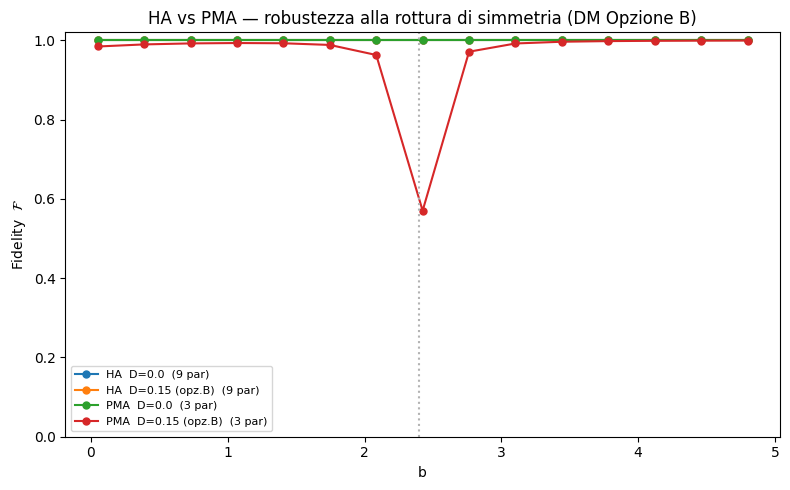

In [11]:
b_vals = np.linspace(0.05, 4.8, 15)
configs = [("HA", None, 0.0, "tab:blue"), ("HA", "B", 0.15, "tab:orange"),
           ("PMA", None, 0.0, "tab:green"), ("PMA", "B", 0.15, "tab:red")]

fig, ax = plt.subplots(figsize=(8, 5))
for at, dm_mode, D, c in configs:
    res = vqe_sweep(b_vals, J=J, Jp=Jp, ansatz_type=at, n_restarts=2,
                     dm_mode=dm_mode, D=D, verbose=False)
    fid = [r["fidelity"] for r in res]
    npar = res[0]["n_params"]
    label = f"{at}  D={D}" + (f" (opz.{dm_mode})" if dm_mode else "") + f"  ({npar} par)"
    ax.plot(b_vals, fid, "-o", color=c, ms=5, label=label)

bc = critical_field(J, Jp)
ax.axvline(bc, color="0.7", ls=":")
ax.set_ylim(0.0, 1.02); ax.set_xlabel("b"); ax.set_ylabel(r"Fidelity  $\mathcal{F}$")
ax.set_title("HA vs PMA — robustezza alla rottura di simmetria (DM Opzione B)")
ax.legend(fontsize=8); fig.tight_layout()
_mostra_figura(fig)

### Perché il PMA crolla: la simmetria

Stessa spiegazione del dimero, adattata al trimero. Il PMA prepara stati con $S_{12}$ e
$M$ definiti. Con $D=0$ va bene, perché $H$ conserva entrambi e il fondamentale li ha
definiti. Con l'Opzione B del DM, $[H,\mathbf S_{12}^2]\neq0$: il vero fondamentale a
$b_c$ è una **miscela** dei blocchi $C$ e $A$, che il PMA **non può rappresentare** (resta
bloccato nel settore scelto dalla preparazione iniziale). La degradazione è massima
proprio dove il mescolamento è massimo ($b_c$), e svanisce lontano dalla soglia —
identico al meccanismo già visto e quantificato in `analisi_dm_trimero.pdf`.

## 8. Esplorazione interattiva

Slider per ansatz, $J$, $J'$, $b$, DM. In particolare **PMA con Opzione B vicino a
$b_c$** mostra la fidelity scendere. (Con `ipywidgets`; altrimenti esempio statico.)

In [12]:
def explore(ansatz_type="PMA", J=1.0, Jp=0.4, b=2.4, dm_choice="B", D=0.15,
            K=1, reps=2, n_restarts=4):
    dm_mode = None if dm_choice == "nessuno" else dm_choice
    o = run_vqe(J, Jp, b, ansatz_type=ansatz_type, reps=reps, K=K,
                n_restarts=n_restarts, dm_mode=dm_mode, D=D)
    used = f"reps={reps}" if ansatz_type == "HA" else f"K={K}"
    print(f"ansatz={ansatz_type} ({used})  J={J}  J'={Jp}  b={b}  DM={dm_choice}(D={D})  ({o['n_params']} parametri)")
    print(f"  E_vqe   = {o['e_vqe']:.5f}")
    print(f"  E_exact = {o['e_exact']:.5f}")
    print(f"  Delta E = {o['delta_e']:+.3e}")
    print(f"  Fidelity= {o['fidelity']:.4f}")
    print(f"  <Mz>    = {o['mz_vqe']:+.3f}")

if HAS_WIDGETS:
    ansatz_dd = Dropdown(options=["HA", "PMA"], value="PMA", description="ansatz_type")
    reps_slider = IntSlider(min=1, max=4, step=1, value=2, description="reps")
    K_slider = IntSlider(min=1, max=3, step=1, value=1, description="K")

    def _sync(change=None):
        is_ha = (ansatz_dd.value == "HA")
        reps_slider.layout.display = "" if is_ha else "none"
        K_slider.layout.display = "none" if is_ha else ""
    ansatz_dd.observe(_sync, names="value")
    _sync()

    interact_manual(explore,
                    ansatz_type=ansatz_dd,
                    J=FloatSlider(min=-2.5, max=2.5, step=0.1, value=1.0),
                    Jp=FloatSlider(min=-2.5, max=2.5, step=0.1, value=0.4),
                    b=FloatSlider(min=0.0, max=5.0, step=0.1, value=2.4),
                    dm_choice=Dropdown(options=["nessuno", "A", "B"], value="B"),
                    D=FloatSlider(min=0.0, max=0.4, step=0.01, value=0.15),
                    K=K_slider, reps=reps_slider,
                    n_restarts=IntSlider(min=1, max=6, step=1, value=4))
else:
    explore("PMA", 1.0, 0.4, 2.4, "B", 0.15)

interactive(children=(Dropdown(description='ansatz_type', index=1, options=('HA', 'PMA'), value='PMA'), FloatS…

## 9. Riepilogo

1. **Principio variazionale:** $\langle H\rangle_{\boldsymbol\theta}\geq E_0$, quindi il VQE
   approssima il ground state **da sopra**.
2. **Estimator:** `StatevectorEstimator`, PUB `(ansatz, H, [params])`, `.evs.item()`.
3. **HA:** generico (`n_local`, Ry+CZ), $3(\text{reps}+1)$ parametri.
4. **PMA (questo notebook):** gate $W_{ij}$ su ciascuno dei 3 legami, stato iniziale a
   $(S_{12},M)$ definiti scelto in base al campo (**branching esplicito**), $3K$ parametri.
   Mirror diretto del PMA "originale" del dimero — non la versione RBS senza branching già
   validata in `vqe_trimer_ring.py`.
5. **Trade-off centrale:** con $D=0$ il PMA batte l'HA a parità di precisione, con meno
   parametri. Con il DM (Opzione B) il PMA crolla vicino a $b_c$ perché conserva
   $S_{12}$ mentre l'Opzione B lo rompe; l'HA generico resta a $\mathcal F=1$ — stessa
   lezione del dimero, confermata su un sistema frustrato a 3 corpi.
6. **Prossimo passo:** notebook di confronto (sul modello di
   `confronto_ansatz_entangler.ipynb`) per esplorare se, con uno schema di rottura di
   simmetria più ricco (più layer, o $R_y$ indipendenti fra i legami), il branching
   diventi evitabile anche per il trimero — come già dimostrato per il dimero con
   `PMA-2q·3`.